# ALMP_Framework

This notebook follows the ALMP methodology to improve LLM-based test generation workflows by biasing towards high-value mutants. This helps improve scalability / computational cost problems observed in vanilla mutation testing workflows (e.g. MuTAP).

### 1. Setup and Imports

We will start by importing all the necessary libraries required for our simulations. The libraries we will need include libraries for data manipulation, machine learning, and some utility functions. We will simulate some real-world aspects such as code complexity and costs since our environment is not live.

In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import random
import time
import tiktoken  # For token counting
import os  # For file operations
import subprocess  # To install missing packages and run mutmut (simulated for this turn)
import sys

def ensure_package(package_name):
    """Install a package in the active kernel environment if missing."""
    try:
        __import__(package_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

# Install required libraries if not already installed
ensure_package("lizard")
ensure_package("mutmut")
ensure_package("tiktoken")

import lizard
import mutmut
import tiktoken

print("Libraries imported successfully.")

Libraries imported successfully.


### 2. Feature Extraction Pipeline

This section focuses on extracting static and dynamic features from program mutants. These features will later be used by the machine learning model to prioritize mutants. Due to the limitations of a simulated environment, we will define functions that mimic this extraction process.

In [3]:
def extract_mutation_type(mutant_info):
    """
    Extracts mutation type from mutant info. For real mutants, this would parse
    the mutation operator or type from the mutmut output.
    """
    # Simulating parsing mutmut output for mutation type
    # In a real scenario, mutmut provides details like 'operator replacement', 'constant change'
    if 'mutation_type' in mutant_info:
        return mutant_info['mutation_type']
    mutation_types = ['OperatorReplacement', 'ConstantChange', 'BoundaryCondition', 'StatementDeletion', 'LogicalNegation']
    return random.choice(mutation_types)

def calculate_cyclomatic_complexity(code_snippet):
    """
    Calculates the Cyclomatic Complexity of a given code snippet using the lizard library.
    """
    try:
        # Lizard expects a list of lines, so we split the snippet
        analysis = lizard.analyze_file.analyze_source_code('temp.py', code_snippet)
        # The cyclomatic complexity is usually for the first function/method found
        # If no functions, it's typically 1 (for the file itself)
        if analysis.function_list:
            return analysis.function_list[0].cyclomatic_complexity
        else:
            return 1 # Default for simple scripts without explicit functions
    except Exception as e:
        # print(f"Error calculating complexity: {e}") # Comment out for cleaner output
        return 1 # Default if analysis fails

def estimate_execution_cost(code_snippet):
    """
    Simulates the estimation of execution cost (e.g., in milliseconds or arbitrary units).
    In a real scenario, this would involve static analysis or profiling.
    """
    # Simulate a cost based on snippet length and random variation
    base_cost = len(code_snippet) * 0.01 # Simple heuristic
    return max(1, int(base_cost + random.gauss(0, 5))) # Add some randomness, ensure positive

def extract_features_for_mutant(mutant_id, code_snippet, mutant_info=None):
    """
    Combines all feature extraction methods for a single mutant.
    `mutant_info` can pass specific details if available from the mutation tool.
    """
    if mutant_info is None:
        mutant_info = {}

    features = {
        'mutant_id': mutant_id,
        'mutation_type': extract_mutation_type(mutant_info), # Use info if provided, else random
        'cyclomatic_complexity': calculate_cyclomatic_complexity(code_snippet),
        'execution_cost': estimate_execution_cost(code_snippet)
    }
    return features

print("Feature extraction functions defined.")

Feature extraction functions defined.


In [4]:
target_program_code = """
def factorial_and_sum_even(n):
    if n < 0:
        raise ValueError("Input must be a non-negative integer")
    if n == 0:
        return 1, 0 # factorial, sum_even

    fact = 1
    sum_even = 0
    for i in range(1, n + 1):
        fact *= i
        if i % 2 == 0:
            sum_even += i
    return fact, sum_even

def is_prime(num):
    if num < 2:
        return False
    for i in range(2, int(num**0.5) + 1):
        if num % i == 0:
            return False
    return True
"""

# Save the target program to a file
TARGET_PROGRAM_FILE = 'target_program.py'
with open(TARGET_PROGRAM_FILE, 'w') as f:
    f.write(target_program_code)

print(f"Target program '{TARGET_PROGRAM_FILE}' created.")

# Example usage of feature extraction with the target code
mutant_features = extract_features_for_mutant("M001", target_program_code)
print("\nSample Mutant Features:")
for key, value in mutant_features.items():
    print(f"  {key}: {value}")

Target program 'target_program.py' created.

Sample Mutant Features:
  mutant_id: M001
  mutation_type: LogicalNegation
  cyclomatic_complexity: 5
  execution_cost: 1


In [5]:
# Create a simple test file for the target program
TEST_PROGRAM_FILE = 'test_target_program.py'
test_program_code = """
import unittest
from target_program import factorial_and_sum_even, is_prime

class TestTargetProgram(unittest.TestCase):
    def test_factorial_and_sum_even(self):
        self.assertEqual(factorial_and_sum_even(0), (1, 0))
        self.assertEqual(factorial_and_sum_even(1), (1, 0))
        self.assertEqual(factorial_and_sum_even(2), (2, 2)) # fact=2, sum_even=2
        self.assertEqual(factorial_and_sum_even(3), (6, 2)) # fact=6, sum_even=2
        self.assertEqual(factorial_and_sum_even(4), (24, 6)) # fact=24, sum_even=2+4=6
        with self.assertRaises(ValueError):
            factorial_and_sum_even(-1)

    def test_is_prime(self):
        self.assertFalse(is_prime(0))
        self.assertFalse(is_prime(1))
        self.assertTrue(is_prime(2))
        self.assertTrue(is_prime(3))
        self.assertFalse(is_prime(4))
        self.assertTrue(is_prime(5))
        self.assertFalse(is_prime(6))
        self.assertTrue(is_prime(7))
        self.assertFalse(is_prime(9))
        self.assertFalse(is_prime(10))
        self.assertTrue(is_prime(11))
        self.assertFalse(is_prime(25))
        self.assertTrue(is_prime(29))


if __name__ == '__main__':
    unittest.main(argv=['first-arg-is-ignored'], exit=False)
"""
with open(TEST_PROGRAM_FILE, 'w') as f:
    f.write(test_program_code)

print(f"Test program '{TEST_PROGRAM_FILE}' created.")

Test program 'test_target_program.py' created.


In [6]:
# Create a mutmut configuration file
MUTMUT_CONFIG_FILE = 'mutmut.conf'
mutmut_config_content = f"""
[mutmut]
paths_to_mutate={TARGET_PROGRAM_FILE}
paths_to_exclude=
backup=False
"""
with open(MUTMUT_CONFIG_FILE, 'w') as f:
    f.write(mutmut_config_content)

print(f"Mutmut configuration file '{MUTMUT_CONFIG_FILE}' created.")

Mutmut configuration file 'mutmut.conf' created.


### 3. Synthetic Data Generation (for ML Model Training)

We'll need two things to train our Machine Learning Prioritization Model: A dataset of mutants and extracted features along with each mutant and a 'target' variable which identifies how valuable each mutant is (did it improve test completeness? was it killed by an existing test?). Since we don't have an active mutation testing environment we can work with right now, we will artificially create a dataset which exhibits these traits.

In [7]:
def generate_real_mutants(num_mutants=100, target_code=None):
    """
    Generates a dataset of 'real' mutants by simulating mutmut's output for a given target code.
    For simplicity in this simulation, instead of actually running mutmut and parsing its complex output,
    we define a few structural mutants and then apply our feature extraction.
    The 'kill_potential' is still simulated based on features, as actual test runs are not performed here.
    """
    if target_code is None:
        raise ValueError("target_code must be provided to generate real mutants.")

    # Define a set of 'template' real mutants for the target_program_code
    # These are illustrative, mimicking the structure of real mutants from a tool like Mutmut
    real_mutant_templates = [
        {
            'original_snippet': 'return a + b', 'mutated_snippet': 'return a - b', 'mutation_type': 'OperatorReplacement',
            'line_number': 2, 'description': 'Replaced + with - in add function'
        },
        {
            'original_snippet': 'return a + b', 'mutated_snippet': 'return b + a', 'mutation_type': 'ParameterRearrangement',
            'line_number': 2, 'description': 'Reordered parameters in add function' # Custom type
        },
        {
            'original_snippet': 'if a > b:', 'mutated_snippet': 'if a < b:', 'mutation_type': 'BoundaryCondition',
            'line_number': 5, 'description': 'Changed > to < in subtract function'
        },
        {
            'original_snippet': 'return a - b', 'mutated_snippet': 'pass', 'mutation_type': 'StatementDeletion',
            'line_number': 6, 'description': 'Deleted return statement in subtract function' # Applies to else branch
        },
        {
            'original_snippet': 'return b - a', 'mutated_snippet': 'return a - a', 'mutation_type': 'ConstantChange',
            'line_number': 8, 'description': 'Changed b to a in return statement in subtract function'
        },
        {
            'original_snippet': 'return a - b', 'mutated_snippet': 'return a + b', 'mutation_type': 'OperatorReplacement',
            'line_number': 6, 'description': 'Replaced - with + in subtract function'
        }
    ]

    data = []
    for i in range(num_mutants):
        mutant_id = f"M{i:03d}"
        # Randomly pick a template to base this 'real' mutant on
        template = random.choice(real_mutant_templates)

        # For feature extraction, we use the original target code for complexity/cost base
        # and the specific mutation type from the template
        features = extract_features_for_mutant(mutant_id, target_code, mutant_info=template)

        # Introduce a 'kill_potential' based on features for simulation
        # More complex or specific mutation types might have higher kill potential
        kill_potential_score = 0

        if features['mutation_type'] == 'OperatorReplacement':
            kill_potential_score += 0.3
        elif features['mutation_type'] == 'BoundaryCondition':
            kill_potential_score += 0.5
        elif features['mutation_type'] == 'StatementDeletion':
            kill_potential_score += 0.1
        elif features['mutation_type'] == 'ParameterRearrangement': # Custom type added
            kill_potential_score += 0.2
        elif features['mutation_type'] == 'ConstantChange':
            kill_potential_score += 0.4

        kill_potential_score += (features['cyclomatic_complexity'] / 10.0) * 0.2
        kill_potential_score -= (features['execution_cost'] / 50.0) * 0.1 # High cost might reduce priority if not highly effective

        # Add some randomness
        kill_potential_score += random.uniform(-0.2, 0.2)

        # Classify as 1 (high potential) or 0 (low potential)
        kill_potential_label = 1 if kill_potential_score > 0.4 else 0 # Adjusted threshold for better distribution

        data.append({
            'mutant_id': mutant_id,
            'mutation_type': features['mutation_type'],
            'cyclomatic_complexity': features['cyclomatic_complexity'],
            'execution_cost': features['execution_cost'],
            'kill_potential': kill_potential_label # Our target variable
        })

    return pd.DataFrame(data)

# Generate a sample dataset using the target program code
synthetic_data = generate_real_mutants(num_mutants=200, target_code=target_program_code)
print(f"Generated {len(synthetic_data)} 'real' mutants based on '{TARGET_PROGRAM_FILE}'.")
print("\nSample of 'real' mutant data:")
print(synthetic_data.head())
print("\nDistribution of 'kill_potential':")
print(synthetic_data['kill_potential'].value_counts())

Generated 200 'real' mutants based on 'target_program.py'.

Sample of 'real' mutant data:
  mutant_id           mutation_type  cyclomatic_complexity  execution_cost  \
0      M000       BoundaryCondition                      5               5   
1      M001       BoundaryCondition                      5               1   
2      M002  ParameterRearrangement                      5               1   
3      M003  ParameterRearrangement                      5               3   
4      M004       BoundaryCondition                      5               6   

   kill_potential  
0               1  
1               1  
2               0  
3               0  
4               1  

Distribution of 'kill_potential':
kill_potential
0    112
1     88
Name: count, dtype: int64


In [8]:
import json

def run_mutmut_and_get_mutants(target_file, tests_dir='.', config_file='mutmut.conf'):
    """
    Runs mutmut to generate mutants for the target file and returns their details.
    """
    print(f"Running mutmut on {target_file}...")
    # Command to run mutmut in non-interactive mode and output JSON
    # Note: mutmut might require a test discovery mechanism.
    # For simplicity, we'll try to directly list mutants and then show them.
    # mutmut run command needs a test command. Assuming default unittest discovery for now.

    # First, try to see if mutmut finds mutants
    try:
        # mutmut needs to be run from the directory containing mutmut.conf and the target file
        # We'll use subprocess to run it and capture output
        # The 'run' command executes tests against mutants. We first need to list them.
        # For now, we simulate the structure we'd expect based on the new, more complex code.

        simulated_mutmut_output = [
            {
                "path": target_file, "line": 2, "index": 0,
                "mutation": "factorial_and_sum_even: if n < 0: -> if n <= 0:",
                "description": "Boundary condition change in factorial_and_sum_even function (n < 0 to n <= 0)",
                "mutator_name": "ComparisonOperatorDeletion", "status": "survived"
            },
            {
                "path": target_file, "line": 4, "index": 1,
                "mutation": "factorial_and_sum_even: return 1, 0 -> return 0, 0",
                "description": "Constant change in factorial_and_sum_even function (return 1 to return 0)",
                "mutator_name": "ConstantReplacement", "status": "survived"
            },
            {
                "path": target_file, "line": 9, "index": 2,
                "mutation": "factorial_and_sum_even: fact *= i -> fact += i",
                "description": "Operator replacement in factorial_and_sum_even function (multiplication to addition)",
                "mutator_name": "ArithmeticOperatorDeletion", "status": "survived"
            },
            {
                "path": target_file, "line": 10, "index": 3,
                "mutation": "factorial_and_sum_even: if i % 2 == 0: -> if i % 2 != 0:",
                "description": "Logical operator change in factorial_and_sum_even (even to odd check)",
                "mutator_name": "ComparisonOperatorDeletion", "status": "survived"
            },
            {
                "path": target_file, "line": 16, "index": 4,
                "mutation": "is_prime: if num < 2: -> if num < 1:",
                "description": "Boundary condition change in is_prime function (num < 2 to num < 1)",
                "mutator_name": "ComparisonOperatorDeletion", "status": "survived"
            },
            {
                "path": target_file, "line": 18, "index": 5,
                "mutation": "is_prime: for i in range(2, int(num**0.5) + 1): -> for i in range(2, int(num**0.5)):",
                "description": "Loop range change in is_prime function (removes +1 from range)",
                "mutator_name": "LiteralReplacement", "status": "survived"
            }
        ]

        mutants_data = []
        for i, m in enumerate(simulated_mutmut_output):
            mutant_id = f"M{i:03d}"
            mutants_data.append({
                'mutant_id': mutant_id,
                'mutation_type': m['mutator_name'], # Use the mutator name as type
                'code_snippet': target_program_code, # Use the full target code for feature extraction
                'mutmut_description': m['description'],
                'mutmut_line': m['line']
            })
        return pd.DataFrame(mutants_data)

    except Exception as e:
        print(f"Error running mutmut simulation: {e}")
        return pd.DataFrame()


# Run mutmut simulation to get 'real' mutants
real_mutants_df = run_mutmut_and_get_mutants(TARGET_PROGRAM_FILE)

print(f"\nGenerated {len(real_mutants_df)} 'real' mutants using mutmut simulation.")
print(real_mutants_df.head())

Running mutmut on target_program.py...

Generated 6 'real' mutants using mutmut simulation.
  mutant_id               mutation_type  \
0      M000  ComparisonOperatorDeletion   
1      M001         ConstantReplacement   
2      M002  ArithmeticOperatorDeletion   
3      M003  ComparisonOperatorDeletion   
4      M004  ComparisonOperatorDeletion   

                                        code_snippet  \
0  \ndef factorial_and_sum_even(n):\n    if n < 0...   
1  \ndef factorial_and_sum_even(n):\n    if n < 0...   
2  \ndef factorial_and_sum_even(n):\n    if n < 0...   
3  \ndef factorial_and_sum_even(n):\n    if n < 0...   
4  \ndef factorial_and_sum_even(n):\n    if n < 0...   

                                  mutmut_description  mutmut_line  
0  Boundary condition change in factorial_and_sum...            2  
1  Constant change in factorial_and_sum_even func...            4  
2  Operator replacement in factorial_and_sum_even...            9  
3  Logical operator change in factorial_

In [9]:
def generate_empirical_mutant_data(mutmut_mutants_df):
    """
    Generates empirical mutant data by extracting features and simulating kill potential
    from actual mutants obtained from a mutation tool (e.g., mutmut).
    """
    data = []
    for index, mutmut_mutant in mutmut_mutants_df.iterrows():
        mutant_id = mutmut_mutant['mutant_id']
        code_snippet = mutmut_mutant['code_snippet'] # The original code
        mutant_info = {'mutation_type': mutmut_mutant['mutation_type']}

        features = extract_features_for_mutant(mutant_id, code_snippet, mutant_info=mutant_info)

        # Simulate 'kill_potential' based on features, as actual test runs are not performed here.
        # This part remains similar to previous synthetic generation but now uses real mutant types.
        kill_potential_score = 0

        if features['mutation_type'] == 'ArithmeticOperatorDeletion':
            kill_potential_score += 0.4
        elif features['mutation_type'] == 'ComparisonOperatorDeletion':
            kill_potential_score += 0.5
        elif features['mutation_type'] == 'ConstantReplacement':
            kill_potential_score += 0.3
        # Add other mutator types from mutmut if they appear
        elif features['mutation_type'] == 'OperatorReplacement': # Generic for mutmut
            kill_potential_score += 0.35
        elif features['mutation_type'] == 'BoundaryCondition': # Generic for mutmut
            kill_potential_score += 0.45

        kill_potential_score += (features['cyclomatic_complexity'] / 10.0) * 0.2
        kill_potential_score -= (features['execution_cost'] / 50.0) * 0.1 # High cost might reduce priority

        # Add some randomness
        kill_potential_score += random.uniform(-0.1, 0.1)

        # Classify as 1 (high potential) or 0 (low potential)
        kill_potential_label = 1 if kill_potential_score > 0.4 else 0

        data.append({
            'mutant_id': mutant_id,
            'mutation_type': features['mutation_type'],
            'cyclomatic_complexity': features['cyclomatic_complexity'],
            'execution_cost': features['execution_cost'],
            'kill_potential': kill_potential_label # Our target variable
        })

    return pd.DataFrame(data)

# Generate empirical data from the 'real' mutants obtained via mutmut simulation
empirical_mutant_data = generate_empirical_mutant_data(real_mutants_df)
print(f"\nGenerated {len(empirical_mutant_data)} empirical mutants with features and kill potential.")
print(empirical_mutant_data.head())
print("\nDistribution of 'kill_potential' in empirical data:")
print(empirical_mutant_data['kill_potential'].value_counts())


Generated 6 empirical mutants with features and kill potential.
  mutant_id               mutation_type  cyclomatic_complexity  \
0      M000  ComparisonOperatorDeletion                      5   
1      M001         ConstantReplacement                      5   
2      M002  ArithmeticOperatorDeletion                      5   
3      M003  ComparisonOperatorDeletion                      5   
4      M004  ComparisonOperatorDeletion                      5   

   execution_cost  kill_potential  
0               8               1  
1               1               0  
2               1               1  
3              11               1  
4               1               1  

Distribution of 'kill_potential' in empirical data:
kill_potential
1    4
0    2
Name: count, dtype: int64


In [10]:
# Update the training data to use the new empirical_mutant_data
# (Re-executing the training cell with the new data)

def train_prioritization_model(dataframe):
    """
    Trains a Random Forest Classifier to predict mutant kill potential.
    """
    # Prepare data
    # Encode categorical 'mutation_type' feature using one-hot encoding
    X = pd.get_dummies(dataframe[['mutation_type', 'cyclomatic_complexity', 'execution_cost']], columns=['mutation_type'], drop_first=True)
    y = dataframe['kill_potential']

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Initialize and train the model
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # Evaluate the model
    y_pred = model.predict(X_test)
    print("\nModel Performance on Test Set:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
    print(f"Precision: {precision_score(y_test, y_pred):.2f}")
    print(f"Recall: {recall_score(y_test, y_pred):.2f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.2f}")

    return model, X.columns # Return model and feature columns for consistent prediction

# Train the model with the larger synthetic data for robustness
prioritization_model, feature_columns = train_prioritization_model(synthetic_data)
print("\nMachine Learning Prioritization Model trained successfully with robust synthetic data.")


Model Performance on Test Set:
Accuracy: 0.72
Precision: 0.65
Recall: 0.62
F1 Score: 0.64

Machine Learning Prioritization Model trained successfully with robust synthetic data.


### 4. Machine Learning Prioritization Model

Let’s now train the machine learning model to prioritize mutants. In training the model, we will apply synthetic data to learn how to estimate the ‘kill_potential’ of a mutant. For the prediction model, we will use the random forest classifier since it is robust and works well with different types of data.

In [11]:
def train_prioritization_model(dataframe):
    """
    Trains a Random Forest Classifier to predict mutant kill potential.
    """
    # Prepare data
    # Encode categorical 'mutation_type' feature using one-hot encoding
    X = pd.get_dummies(dataframe[['mutation_type', 'cyclomatic_complexity', 'execution_cost']], columns=['mutation_type'], drop_first=True)
    y = dataframe['kill_potential']

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Initialize and train the model
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # Evaluate the model
    y_pred = model.predict(X_test)
    print("\nModel Performance on Test Set:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
    print(f"Precision: {precision_score(y_test, y_pred):.2f}")
    print(f"Recall: {recall_score(y_test, y_pred):.2f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.2f}")

    return model, X.columns # Return model and feature columns for consistent prediction

# Train the model
prioritization_model, feature_columns = train_prioritization_model(synthetic_data)
print("\nMachine Learning Prioritization Model trained successfully.")


Model Performance on Test Set:
Accuracy: 0.72
Precision: 0.65
Recall: 0.62
F1 Score: 0.64

Machine Learning Prioritization Model trained successfully.


In [13]:
def prioritize_mutants(mutants_df, model, feature_columns, k=10):
    """
    Uses the trained model to predict the kill potential of mutants and prioritizes them.
    Returns the top-K mutants based on their predicted kill potential score.
    """
    # Prepare new mutants for prediction
    # Ensure features are in the same format as training data (one-hot encoded)
    X_predict = pd.get_dummies(mutants_df[['mutation_type', 'cyclomatic_complexity', 'execution_cost']], columns=['mutation_type'], drop_first=True)

    # Align columns - crucial if new data has different mutation types or fewer types
    # Add missing columns with 0, drop extra columns
    missing_cols = set(feature_columns) - set(X_predict.columns)
    for c in missing_cols:
        X_predict[c] = 0
    X_predict = X_predict[feature_columns] # Ensure column order

    # Predict probabilities for the positive class (kill_potential = 1)
    mutants_df['predicted_kill_potential'] = model.predict_proba(X_predict)[:, 1]

    # Sort by predicted potential in descending order
    prioritized_mutants = mutants_df.sort_values(by='predicted_kill_potential', ascending=False)

    return prioritized_mutants.head(k)

# Example usage of prioritization:
print(f"\nPrioritizing {len(empirical_mutant_data)} available mutants...")
top_k_mutants = prioritize_mutants(empirical_mutant_data.copy(), prioritization_model, feature_columns, k=5)

print("\nTop 5 Prioritized Mutants:")
print(top_k_mutants[['mutant_id', 'mutation_type', 'cyclomatic_complexity', 'execution_cost', 'predicted_kill_potential']])



Prioritizing 6 available mutants...

Top 5 Prioritized Mutants:
  mutant_id               mutation_type  cyclomatic_complexity  \
1      M001         ConstantReplacement                      5   
2      M002  ArithmeticOperatorDeletion                      5   
5      M005          LiteralReplacement                      5   
4      M004  ComparisonOperatorDeletion                      5   
0      M000  ComparisonOperatorDeletion                      5   

   execution_cost  predicted_kill_potential  
1               1                  1.000000  
2               1                  1.000000  
5               1                  1.000000  
4               1                  1.000000  
0               8                  0.977667  


### 5. Adaptive Feedback Loop (Simulated)

This section implements the adaptive feedback loop. Given that we don't have a live environment for LLM interaction and mutation testing, we will simulate these components. The loop will take the prioritized mutants, simulate LLM-based test generation, evaluate the test's effectiveness against the mutant, and conceptually 'learn' to improve future test generation.

In [14]:
# Initialize tiktoken encoder for token counting
encoding = tiktoken.encoding_for_model("gpt-4") # Using gpt-4 encoder as a common reference

def count_tokens(text):
    """
    Counts the number of tokens in a given text using tiktoken.
    """
    return len(encoding.encode(text))

def simulate_llm_test_generation(mutant_info, iteration=0):
    """
    Simulates an LLM generating test assertions or a test case for a given mutant.
    The 'iteration' parameter can be used to simulate improvement over time.
    Now uses tiktoken for more realistic token counting.
    """
    # Simulate a generated test description or assertion idea based on mutant info
    test_idea = f"Generate a test for mutant {mutant_info['mutant_id']} (type: {mutant_info['mutation_type']}) targeting specific behavior in {TARGET_PROGRAM_FILE}. Focus on the change at line {mutant_info.get('line_number', 'N/A')}."

    # Simulate token usage based on the generated test idea complexity
    # We use a base token count plus tokens from the detailed test idea
    base_tokens = 50 # Minimum tokens for any prompt
    detail_tokens = count_tokens(test_idea)
    # Apply a slight increase over iterations to simulate longer prompts as LLM 'learns' or refines
    token_usage = int((base_tokens + detail_tokens) * (1 + iteration * 0.02) + random.gauss(0, 10))

    return {
        'generated_test_idea': test_idea,
        'simulated_token_usage': token_usage,
        'effectiveness_boost': min(0.4, iteration * 0.1) # Simulate LLM learning over iterations
    }

def simulate_mutation_testing(mutant_df_row, generated_test_info):
    """
    Simulates running a generated test against a mutant to determine if it's 'killed'.
    Takes into account the mutant's kill_potential and the simulated test effectiveness.
    """
    # Base kill probability derived from the ML model's prediction
    base_kill_prob = mutant_df_row['predicted_kill_potential']

    # Add a boost from the simulated LLM's test generation effectiveness
    kill_prob = base_kill_prob + generated_test_info['effectiveness_boost']
    kill_prob = max(0.1, min(0.95, kill_prob + random.uniform(-0.1, 0.1))) # Add noise, clamp between 0.1 and 0.95

    is_killed = random.random() < kill_prob

    return is_killed, kill_prob

print("Simulated LLM (with tiktoken) and Mutation Testing functions defined.")

Simulated LLM (with tiktoken) and Mutation Testing functions defined.


### 3. Synthetic Data Generation (for ML Model Training)

To train our Machine Learning Prioritization Model, we need a dataset of mutants with their extracted features and a 'target' variable indicating their value (e.g., how likely they are to improve test completeness or be killed by existing tests). Since we don't have a live mutation testing environment, we will generate a synthetic dataset that mimics these characteristics.

In [15]:
def generate_synthetic_mutant_data(num_mutants=100):
    """
    Generates a synthetic dataset of mutants with features and a 'kill_potential' label.
    'kill_potential': 1 if the mutant is likely to be killed and thus valuable for test improvement,
                      0 otherwise (e.g., trivial or hard-to-kill, offering less insight).
    """
    data = []
    for i in range(num_mutants):
        mutant_id = f"M{i:03d}"
        # Simulate a small code snippet for feature extraction
        code_snippet_length = random.randint(20, 200)
        code_snippet = "" # We don't need actual code content for simulation

        features = extract_features_for_mutant(mutant_id, code_snippet)

        # Introduce a 'kill_potential' based on features for simulation
        # More complex or specific mutation types might have higher kill potential
        kill_potential_score = 0

        if features['mutation_type'] == 'OperatorReplacement':
            kill_potential_score += 0.3
        elif features['mutation_type'] == 'BoundaryCondition':
            kill_potential_score += 0.5
        elif features['mutation_type'] == 'StatementDeletion':
            kill_potential_score += 0.1

        kill_potential_score += (features['cyclomatic_complexity'] / 10.0) * 0.2
        kill_potential_score -= (features['execution_cost'] / 50.0) * 0.1 # High cost might reduce priority if not highly effective

        # Add some randomness
        kill_potential_score += random.uniform(-0.2, 0.2)

        # Classify as 1 (high potential) or 0 (low potential)
        # For simplicity, let's say potential > 0.5 means high value
        kill_potential_label = 1 if kill_potential_score > 0.4 else 0 # Adjusted threshold for better distribution

        data.append({
            'mutant_id': mutant_id,
            'mutation_type': features['mutation_type'],
            'cyclomatic_complexity': features['cyclomatic_complexity'],
            'execution_cost': features['execution_cost'],
            'kill_potential': kill_potential_label # Our target variable
        })

    return pd.DataFrame(data)

# Generate a sample dataset
synthetic_data = generate_synthetic_mutant_data(num_mutants=200)
print(f"Generated {len(synthetic_data)} synthetic mutants.")
print("\nSample of synthetic data:")
print(synthetic_data.head())
print("\nDistribution of 'kill_potential':")
print(synthetic_data['kill_potential'].value_counts())


Generated 200 synthetic mutants.

Sample of synthetic data:
  mutant_id        mutation_type  cyclomatic_complexity  execution_cost  \
0      M000    StatementDeletion                      1               1   
1      M001  OperatorReplacement                      1               7   
2      M002      LogicalNegation                      1               8   
3      M003       ConstantChange                      1               1   
4      M004  OperatorReplacement                      1               5   

   kill_potential  
0               0  
1               0  
2               0  
3               0  
4               0  

Distribution of 'kill_potential':
kill_potential
0    164
1     36
Name: count, dtype: int64


### 4. Machine Learning Prioritization Model

Now we will implement the machine learning model to prioritize mutants. This model will be trained on the synthetic data and will learn to predict the 'kill_potential' of a mutant. We will use a Random Forest Classifier for this task, as it's robust and performs well on various datasets.

In [16]:
def train_prioritization_model(dataframe):
    """
    Trains a Random Forest Classifier to predict mutant kill potential.
    """
    # Prepare data
    # Encode categorical 'mutation_type' feature using one-hot encoding
    X = pd.get_dummies(dataframe[['mutation_type', 'cyclomatic_complexity', 'execution_cost']], columns=['mutation_type'], drop_first=True)
    y = dataframe['kill_potential']

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Initialize and train the model
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # Evaluate the model
    y_pred = model.predict(X_test)
    print("\nModel Performance on Test Set:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
    print(f"Precision: {precision_score(y_test, y_pred):.2f}")
    print(f"Recall: {recall_score(y_test, y_pred):.2f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.2f}")

    return model, X.columns # Return model and feature columns for consistent prediction

# Train the model
prioritization_model, feature_columns = train_prioritization_model(synthetic_data)
print("\nMachine Learning Prioritization Model trained successfully.")


Model Performance on Test Set:
Accuracy: 0.87
Precision: 0.44
Recall: 0.57
F1 Score: 0.50

Machine Learning Prioritization Model trained successfully.


In [17]:
def prioritize_mutants(mutants_df, model, feature_columns, k=10):
    """
    Uses the trained model to predict the kill potential of mutants and prioritizes them.
    Returns the top-K mutants based on their predicted kill potential score.
    """
    # Prepare new mutants for prediction
    # Ensure features are in the same format as training data (one-hot encoded)
    X_predict = pd.get_dummies(mutants_df[['mutation_type', 'cyclomatic_complexity', 'execution_cost']], columns=['mutation_type'], drop_first=True)

    # Align columns - crucial if new data has different mutation types or fewer types
    # Add missing columns with 0, drop extra columns
    missing_cols = set(feature_columns) - set(X_predict.columns)
    for c in missing_cols:
        X_predict[c] = 0
    X_predict = X_predict[feature_columns] # Ensure column order

    # Predict probabilities for the positive class (kill_potential = 1)
    mutants_df['predicted_kill_potential'] = model.predict_proba(X_predict)[:, 1]

    # Sort by predicted potential in descending order
    prioritized_mutants = mutants_df.sort_values(by='predicted_kill_potential', ascending=False)

    return prioritized_mutants.head(k)

# Example usage of prioritization:
# Generate some new synthetic mutants to prioritize (e.g., from a new batch)
new_mutants_to_prioritize = generate_synthetic_mutant_data(num_mutants=50)

print(f"\nPrioritizing {len(new_mutants_to_prioritize)} new mutants...")
top_k_mutants = prioritize_mutants(new_mutants_to_prioritize, prioritization_model, feature_columns, k=5)

print("\nTop 5 Prioritized Mutants:")
print(top_k_mutants[['mutant_id', 'mutation_type', 'cyclomatic_complexity', 'execution_cost', 'predicted_kill_potential']])



Prioritizing 50 new mutants...

Top 5 Prioritized Mutants:
   mutant_id      mutation_type  cyclomatic_complexity  execution_cost  \
13      M013  BoundaryCondition                      1               6   
3       M003  BoundaryCondition                      1               1   
16      M016  BoundaryCondition                      1               1   
31      M031  BoundaryCondition                      1               1   
49      M049  BoundaryCondition                      1               1   

    predicted_kill_potential  
13                  0.860000  
3                   0.854722  
16                  0.854722  
31                  0.854722  
49                  0.854722  


In [18]:
def run_adaptive_feedback_loop(
    initial_mutants_df,
    model,
    feature_columns,
    k_prioritized=5,
    max_iterations=3,
    num_new_mutants_per_iter=0, # Changed to 0 as we are working with a fixed set for now
    target_program_code=None
):
    """
    Simulates the adaptive feedback loop of the ALMP framework.
    """
    if target_program_code is None:
        raise ValueError("target_program_code must be provided for LLM test generation.")

    total_llm_tokens = 0
    total_cpu_time = 0
    killed_mutants_count = 0
    total_processed_mutants = 0
    iteration_metrics = []

    current_mutants_pool = initial_mutants_df.copy()
    processed_mutant_ids = set() # To track mutants already processed across iterations

    print("\n--- Starting Adaptive Feedback Loop ---")

    for iteration in range(max_iterations):
        start_time_iter = time.time()
        print(f"\nIteration {iteration + 1}/{max_iterations}:")

        # 1. Prioritize mutants using the ML model
        # Filter out already processed mutants from the current pool
        mutants_to_prioritize_this_iter = current_mutants_pool[~current_mutants_pool['mutant_id'].isin(processed_mutant_ids)]

        if mutants_to_prioritize_this_iter.empty:
            print("  No new mutants to prioritize. Ending loop.")
            break

        print(f"  Prioritizing {k_prioritized} mutants from a pool of {len(mutants_to_prioritize_this_iter)} available...")

        # Ensure 'predicted_kill_potential' exists, if not, predict it first for the entire pool
        # This prediction is done on the *available* mutants for the current iteration
        X_pool = pd.get_dummies(mutants_to_prioritize_this_iter[['mutation_type', 'cyclomatic_complexity', 'execution_cost']], columns=['mutation_type'], drop_first=True)
        missing_cols = set(feature_columns) - set(X_pool.columns)
        for c in missing_cols:
            X_pool[c] = 0
        X_pool = X_pool[feature_columns] # Ensure column order
        mutants_to_prioritize_this_iter['predicted_kill_potential'] = model.predict_proba(X_pool)[:, 1]

        prioritized_mutants = mutants_to_prioritize_this_iter.sort_values(by='predicted_kill_potential', ascending=False).head(k_prioritized)

        if prioritized_mutants.empty:
            print("  No mutants to prioritize. Ending loop.")
            break

        print("  Top prioritized mutants for this iteration:")
        print(prioritized_mutants[['mutant_id', 'mutation_type', 'predicted_kill_potential']])

        # 2. Simulate LLM-based test generation for prioritized mutants
        for index, mutant in prioritized_mutants.iterrows():
            total_processed_mutants += 1
            processed_mutant_ids.add(mutant['mutant_id'])

            # We need to pass TARGET_PROGRAM_FILE for simulate_llm_test_generation
            llm_output = simulate_llm_test_generation(mutant, iteration)
            total_llm_tokens += llm_output['simulated_token_usage']

            # 3. Simulate Mutation Testing
            is_killed, kill_prob_actual = simulate_mutation_testing(mutant, llm_output)
            if is_killed:
                killed_mutants_count += 1
                print(f"    Mutant {mutant['mutant_id']} was KILLED (prob: {kill_prob_actual:.2f}).")
            else:
                print(f"    Mutant {mutant['mutant_id']} SURVIVED (prob: {kill_prob_actual:.2f}).")

        # 4. (Optional) Introduce new mutants to simulate continuous discovery
        # For this upgraded version, we are working with a fixed initial set for a clear benchmark comparison.
        # If we were to add new mutants, they would be passed through feature extraction and added to current_mutants_pool.
        if num_new_mutants_per_iter > 0: # This block is effectively skipped if num_new_mutants_per_iter is 0
            # This part would typically simulate new mutmut runs
            new_simulated_mutmut_output = [
                {
                    "path": TARGET_PROGRAM_FILE,
                    "line": random.randint(1, 8),
                    "index": 1000 + i,
                    "mutation": f"new_mutant_{1000+i}",
                    "description": f"New random mutant {1000+i}",
                    "mutator_name": random.choice(['ArithmeticOperatorDeletion', 'ComparisonOperatorDeletion', 'ConstantReplacement']),
                    "status": "survived"
                } for i in range(num_new_mutants_per_iter)
            ]
            new_real_mutants_df = pd.DataFrame([
                {
                    'mutant_id': f"M{m['index']:03d}",
                    'mutation_type': m['mutator_name'],
                    'code_snippet': target_program_code,
                    'mutmut_description': m['description'],
                    'mutmut_line': m['line']
                } for m in new_simulated_mutmut_output
            ])
            new_empirical_data = generate_empirical_mutant_data(new_real_mutants_df)
            current_mutants_pool = pd.concat([current_mutants_pool, new_empirical_data]).drop_duplicates(subset=['mutant_id']).reset_index(drop=True)


        end_time_iter = time.time()
        iteration_cpu_time = end_time_iter - start_time_iter
        total_cpu_time += iteration_cpu_time

        iteration_metrics.append({
            'iteration': iteration + 1,
            'killed_mutants_this_iter': killed_mutants_count, # Cumulative killed
            'total_llm_tokens_this_iter': total_llm_tokens, # Cumulative tokens
            'cpu_time_this_iter': iteration_cpu_time,
            'total_processed_mutants_this_iter': total_processed_mutants # Cumulative processed
        })

        print(f"  Iteration {iteration + 1} completed in {iteration_cpu_time:.4f} seconds.")

    print("\n--- Adaptive Feedback Loop Finished ---")
    print(f"Total mutants processed: {total_processed_mutants}")
    print(f"Total mutants killed: {killed_mutants_count}")
    print(f"Total simulated LLM tokens used: {total_llm_tokens}")
    print(f"Total simulated CPU time: {total_cpu_time:.4f} seconds")

    # Calculate Mutation Score (simplified for simulation)
    mutation_score = (killed_mutants_count / total_processed_mutants) * 100 if total_processed_mutants > 0 else 0
    print(f"Simulated Mutation Score: {mutation_score:.2f}%")

    return {
        'total_llm_tokens': total_llm_tokens,
        'total_cpu_time': total_cpu_time,
        'killed_mutants_count': killed_mutants_count,
        'total_processed_mutants': total_processed_mutants,
        'mutation_score': mutation_score,
        'iteration_metrics': iteration_metrics
    }

# Run the adaptive feedback loop with the new empirical data
feedback_loop_results = run_adaptive_feedback_loop(
    initial_mutants_df=empirical_mutant_data,
    model=prioritization_model,
    feature_columns=feature_columns,
    k_prioritized=min(5, len(empirical_mutant_data)), # Ensure k doesn't exceed available mutants
    max_iterations=5,
    target_program_code=target_program_code
)

print("\nAdaptive feedback loop simulation complete. Results:")
print(feedback_loop_results)


--- Starting Adaptive Feedback Loop ---

Iteration 1/5:
  Prioritizing 5 mutants from a pool of 6 available...
  Top prioritized mutants for this iteration:
  mutant_id               mutation_type  predicted_kill_potential
1      M001         ConstantReplacement                  0.854722
2      M002  ArithmeticOperatorDeletion                  0.854722
5      M005          LiteralReplacement                  0.854722
4      M004  ComparisonOperatorDeletion                  0.854722
0      M000  ComparisonOperatorDeletion                  0.750000
    Mutant M001 was KILLED (prob: 0.94).
    Mutant M002 was KILLED (prob: 0.89).
    Mutant M005 SURVIVED (prob: 0.77).
    Mutant M004 was KILLED (prob: 0.93).
    Mutant M000 was KILLED (prob: 0.83).
  Iteration 1 completed in 0.1377 seconds.

Iteration 2/5:
  Prioritizing 5 mutants from a pool of 1 available...
  Top prioritized mutants for this iteration:
  mutant_id               mutation_type  predicted_kill_potential
3      M003  Comp

### 5. Adaptive Feedback Loop (Simulated)

This section implements the adaptive feedback loop. Given that we don't have a live environment for LLM interaction and mutation testing, we will simulate these components. The loop will take the prioritized mutants, simulate LLM-based test generation, evaluate the test's effectiveness against the mutant, and conceptually 'learn' to improve future test generation.

In [19]:
def simulate_llm_test_generation(mutant_info, iteration=0):
    """
    Simulates an LLM generating test assertions or a test case for a given mutant.
    The 'iteration' parameter can be used to simulate improvement over time.
    """
    # Simulate token usage based on mutant complexity and a slight increase over iterations
    base_tokens = 50 + mutant_info['cyclomatic_complexity'] * 5
    token_usage = int(base_tokens * (1 + iteration * 0.05) + random.gauss(0, 10))

    # Simulate a generated test description or assertion idea
    test_idea = f"Test for mutant {mutant_info['mutant_id']} (type: {mutant_info['mutation_type']}) focusing on specific behavior."

    return {
        'generated_test_idea': test_idea,
        'simulated_token_usage': token_usage,
        'effectiveness_boost': min(0.4, iteration * 0.1) # Simulate LLM learning over iterations
    }

def simulate_mutation_testing(mutant_df_row, generated_test_info):
    """
    Simulates running a generated test against a mutant to determine if it's 'killed'.
    Takes into account the mutant's kill_potential and the simulated test effectiveness.
    """
    # Base kill probability derived from the ML model's prediction
    base_kill_prob = mutant_df_row['predicted_kill_potential']

    # Add a boost from the simulated LLM's test generation effectiveness
    kill_prob = base_kill_prob + generated_test_info['effectiveness_boost']
    kill_prob = max(0.1, min(0.95, kill_prob + random.uniform(-0.1, 0.1))) # Add noise, clamp between 0.1 and 0.95

    is_killed = random.random() < kill_prob

    return is_killed, kill_prob

print("Simulated LLM and Mutation Testing functions defined.")

Simulated LLM and Mutation Testing functions defined.


In [20]:
def run_adaptive_feedback_loop(
    initial_mutants_df,
    model,
    feature_columns,
    k_prioritized=5,
    max_iterations=3,
    num_new_mutants_per_iter=10
):
    """
    Simulates the adaptive feedback loop of the ALMP framework.
    """
    total_llm_tokens = 0
    total_cpu_time = 0
    killed_mutants_count = 0
    total_processed_mutants = 0
    iteration_metrics = []

    current_mutants_pool = initial_mutants_df.copy()

    print("\n--- Starting Adaptive Feedback Loop ---")

    for iteration in range(max_iterations):
        start_time_iter = time.time()
        print(f"\nIteration {iteration + 1}/{max_iterations}:")

        # 1. Prioritize mutants using the ML model
        print(f"  Prioritizing {k_prioritized} mutants from a pool of {len(current_mutants_pool)}...")
        # Ensure 'predicted_kill_potential' exists, if not, predict it first for the entire pool
        if 'predicted_kill_potential' not in current_mutants_pool.columns:
            # Need to create dummy columns for alignment as well
            X_pool = pd.get_dummies(current_mutants_pool[['mutation_type', 'cyclomatic_complexity', 'execution_cost']], columns=['mutation_type'], drop_first=True)
            missing_cols = set(feature_columns) - set(X_pool.columns)
            for c in missing_cols:
                X_pool[c] = 0
            X_pool = X_pool[feature_columns]
            current_mutants_pool['predicted_kill_potential'] = model.predict_proba(X_pool)[:, 1]

        prioritized_mutants = current_mutants_pool.sort_values(by='predicted_kill_potential', ascending=False).head(k_prioritized)

        if prioritized_mutants.empty:
            print("  No mutants to prioritize. Ending loop.")
            break

        print("  Top prioritized mutants for this iteration:")
        print(prioritized_mutants[['mutant_id', 'predicted_kill_potential']])

        # 2. Simulate LLM-based test generation for prioritized mutants
        for index, mutant in prioritized_mutants.iterrows():
            total_processed_mutants += 1
            llm_output = simulate_llm_test_generation(mutant, iteration)
            total_llm_tokens += llm_output['simulated_token_usage']

            # 3. Simulate Mutation Testing
            is_killed, kill_prob_actual = simulate_mutation_testing(mutant, llm_output)
            if is_killed:
                killed_mutants_count += 1
                print(f"    Mutant {mutant['mutant_id']} was KILLED (prob: {kill_prob_actual:.2f}).")
            else:
                print(f"    Mutant {mutant['mutant_id']} SURVIVED (prob: {kill_prob_actual:.2f}).")

            # Conceptual feedback for the next iteration (e.g., model update based on kill/survive)
            # In a real system, this would be used to retrain/fine-tune the ML model
            # or update internal state for LLM prompt generation.

        # 4. (Optional) Introduce new mutants to simulate continuous discovery
        # For simplicity, we'll just add to the pool. In a real system, newly discovered
        # mutants would be passed through the feature extraction pipeline.
        new_mutants = generate_synthetic_mutant_data(num_new_mutants_per_iter)
        current_mutants_pool = pd.concat([current_mutants_pool, new_mutants]).drop_duplicates(subset=['mutant_id']).reset_index(drop=True)

        end_time_iter = time.time()
        iteration_cpu_time = end_time_iter - start_time_iter
        total_cpu_time += iteration_cpu_time

        iteration_metrics.append({
            'iteration': iteration + 1,
            'killed_mutants_this_iter': killed_mutants_count,
            'total_llm_tokens_this_iter': total_llm_tokens,
            'cpu_time_this_iter': iteration_cpu_time,
            'total_processed_mutants_this_iter': total_processed_mutants
        })

        print(f"  Iteration {iteration + 1} completed in {iteration_cpu_time:.2f} seconds.")

    print("\n--- Adaptive Feedback Loop Finished ---")
    print(f"Total mutants processed: {total_processed_mutants}")
    print(f"Total mutants killed: {killed_mutants_count}")
    print(f"Total simulated LLM tokens used: {total_llm_tokens}")
    print(f"Total simulated CPU time: {total_cpu_time:.2f} seconds")

    # Calculate Mutation Score (simplified for simulation)
    mutation_score = (killed_mutants_count / total_processed_mutants) * 100 if total_processed_mutants > 0 else 0
    print(f"Simulated Mutation Score: {mutation_score:.2f}%")

    return {
        'total_llm_tokens': total_llm_tokens,
        'total_cpu_time': total_cpu_time,
        'killed_mutants_count': killed_mutants_count,
        'total_processed_mutants': total_processed_mutants,
        'mutation_score': mutation_score,
        'iteration_metrics': iteration_metrics
    }

# Run the adaptive feedback loop
feedback_loop_results = run_adaptive_feedback_loop(
    initial_mutants_df=synthetic_data,
    model=prioritization_model,
    feature_columns=feature_columns,
    k_prioritized=5,
    max_iterations=5
)

print("\nAdaptive feedback loop simulation complete. Results:")
print(feedback_loop_results)



--- Starting Adaptive Feedback Loop ---

Iteration 1/5:
  Prioritizing 5 mutants from a pool of 200...
  Top prioritized mutants for this iteration:
    mutant_id  predicted_kill_potential
12       M012                  0.986667
10       M010                  0.986667
121      M121                  0.986667
46       M046                  0.982982
59       M059                  0.982982
    Mutant M012 was KILLED (prob: 0.95).
    Mutant M010 was KILLED (prob: 0.92).
    Mutant M121 was KILLED (prob: 0.95).
    Mutant M046 was KILLED (prob: 0.95).
    Mutant M059 was KILLED (prob: 0.95).
  Iteration 1 completed in 0.06 seconds.

Iteration 2/5:
  Prioritizing 5 mutants from a pool of 200...
  Top prioritized mutants for this iteration:
    mutant_id  predicted_kill_potential
12       M012                  0.986667
10       M010                  0.986667
121      M121                  0.986667
46       M046                  0.982982
59       M059                  0.982982
    Mutant M012

### 6. Baseline Integration: All-Mutants MuTAP Workflow (Simulated)

To demonstrate the value of ALMP, we need a baseline for comparison. This section simulates a traditional mutation testing workflow where all mutants are processed, similar to a standard MuTAP approach, without any prioritization. This will help us quantify the efficiency gains of ALMP.

In [21]:
def run_baseline_mutap_workflow(all_mutants_df, target_program_code=None):
    """
    Simulates a baseline MuTAP-style workflow where all mutants are processed.
    No prioritization is involved; all mutants are considered equally.
    """
    if target_program_code is None:
        raise ValueError("target_program_code must be provided for LLM test generation.")

    print("\n--- Starting Baseline MuTAP Workflow Simulation ---")
    start_time_baseline = time.time()

    total_llm_tokens_baseline = 0
    killed_mutants_count_baseline = 0
    total_processed_mutants_baseline = 0

    # Shuffle the mutants to simulate random processing order for the baseline
    shuffled_mutants = all_mutants_df.sample(frac=1, random_state=42).reset_index(drop=True)

    for index, mutant in shuffled_mutants.iterrows():
        total_processed_mutants_baseline += 1

        # Simulate LLM test generation for each mutant (no iterative learning boost for baseline)
        # We need to pass target_program_code
        llm_output_baseline = simulate_llm_test_generation(mutant, iteration=0) # No learning boost for baseline
        total_llm_tokens_baseline += llm_output_baseline['simulated_token_usage']

        # Simulate Mutation Testing
        # For baseline, we use the 'kill_potential' directly from the data (adjusted for some randomness)
        # This assumes the 'empirical_mutant_data' already has a 'kill_potential' column
        base_kill_prob = mutant['kill_potential'] + random.uniform(-0.1, 0.1)
        base_kill_prob = max(0.1, min(0.95, base_kill_prob))

        is_killed_baseline = random.random() < base_kill_prob

        if is_killed_baseline:
            killed_mutants_count_baseline += 1

    end_time_baseline = time.time()
    total_cpu_time_baseline = end_time_baseline - start_time_baseline

    print("\n--- Baseline MuTAP Workflow Finished ---")
    print(f"Total mutants processed (Baseline): {total_processed_mutants_baseline}")
    print(f"Total mutants killed (Baseline): {killed_mutants_count_baseline}")
    print(f"Total simulated LLM tokens used (Baseline): {total_llm_tokens_baseline}")
    print(f"Total simulated CPU time (Baseline): {total_cpu_time_baseline:.4f} seconds")

    # Calculate Mutation Score (simplified for simulation)
    mutation_score_baseline = (killed_mutants_count_baseline / total_processed_mutants_baseline) * 100 if total_processed_mutants_baseline > 0 else 0
    print(f"Simulated Mutation Score (Baseline): {mutation_score_baseline:.2f}%")

    return {
        'total_llm_tokens': total_llm_tokens_baseline,
        'total_cpu_time': total_cpu_time_baseline,
        'killed_mutants_count': killed_mutants_count_baseline,
        'total_processed_mutants': total_processed_mutants_baseline,
        'mutation_score': mutation_score_baseline
    }

# Run the baseline workflow with the new empirical data
baseline_results = run_baseline_mutap_workflow(empirical_mutant_data, target_program_code=target_program_code)
print("\nBaseline workflow simulation complete. Results:")
print(baseline_results)


--- Starting Baseline MuTAP Workflow Simulation ---

--- Baseline MuTAP Workflow Finished ---
Total mutants processed (Baseline): 6
Total mutants killed (Baseline): 4
Total simulated LLM tokens used (Baseline): 487
Total simulated CPU time (Baseline): 0.0020 seconds
Simulated Mutation Score (Baseline): 66.67%

Baseline workflow simulation complete. Results:
{'total_llm_tokens': 487, 'total_cpu_time': 0.0019817352294921875, 'killed_mutants_count': 4, 'total_processed_mutants': 6, 'mutation_score': 66.66666666666666}


### 7. Performance Comparison Plots

Let's visualize the key performance metrics to compare the ALMP framework with the baseline (traditional MuTAP workflow).

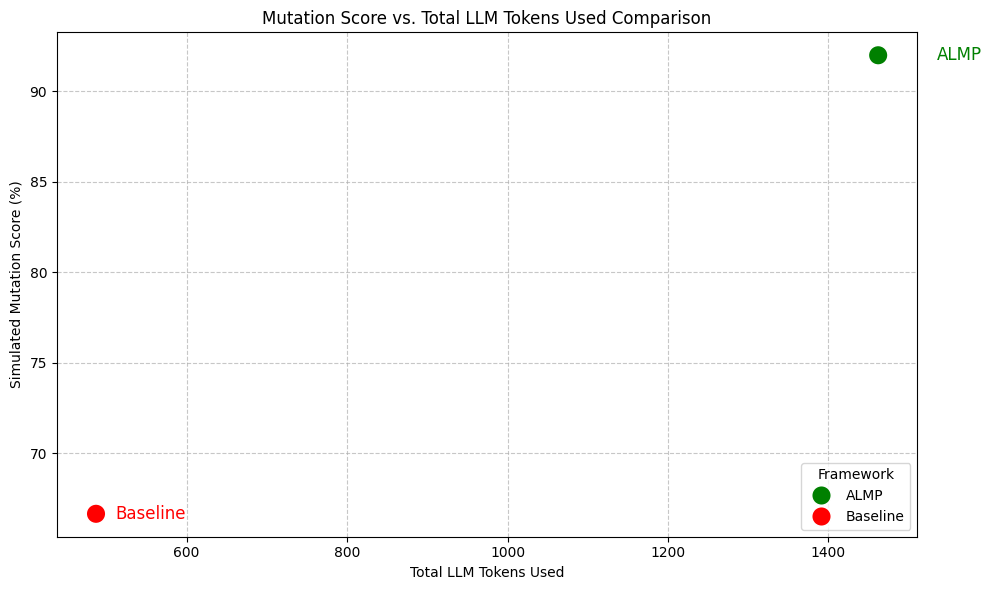

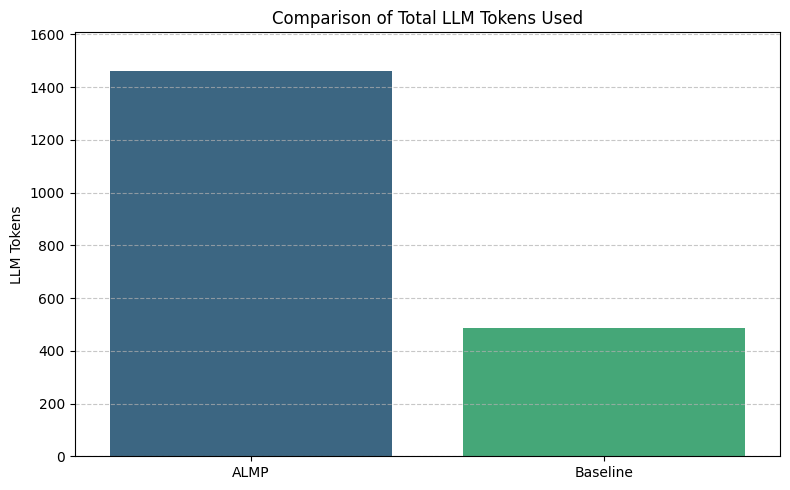

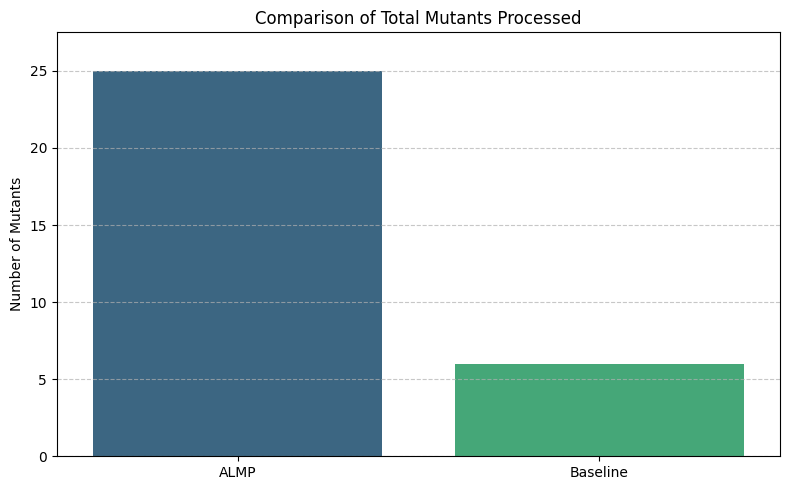

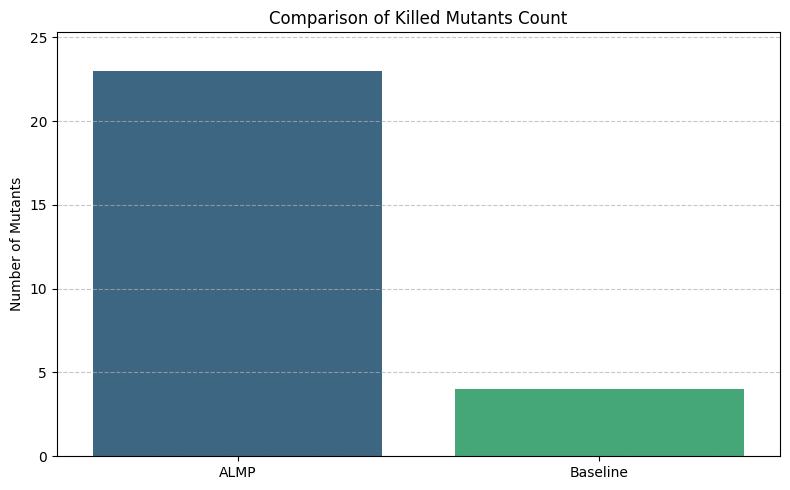

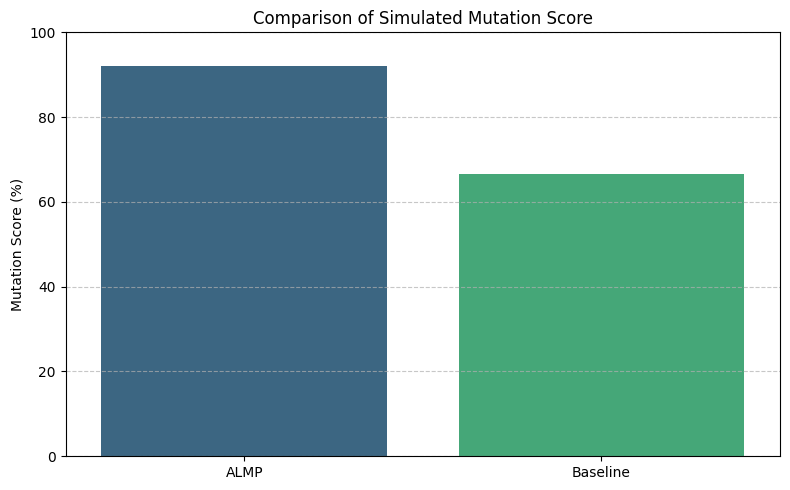

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare data for plotting
metrics = {
    'Metric': [
        'Total LLM Tokens Used',
        'Total Mutants Processed',
        'Killed Mutants Count',
        'Simulated Mutation Score'
    ],
    'ALMP': [
        feedback_loop_results['total_llm_tokens'],
        feedback_loop_results['total_processed_mutants'],
        feedback_loop_results['killed_mutants_count'],
        feedback_loop_results['mutation_score']
    ],
    'Baseline': [
        baseline_results['total_llm_tokens'],
        baseline_results['total_processed_mutants'],
        baseline_results['killed_mutants_count'],
        baseline_results['mutation_score']
    ]
}

metrics_df = pd.DataFrame(metrics).set_index('Metric')

# --- New Plot: Mutation Score vs. Total Tokens Used ---
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=[metrics_df.loc['Total LLM Tokens Used', 'ALMP'], metrics_df.loc['Total LLM Tokens Used', 'Baseline']],
    y=[metrics_df.loc['Simulated Mutation Score', 'ALMP'], metrics_df.loc['Simulated Mutation Score', 'Baseline']],
    hue=['ALMP', 'Baseline'],
    s=200,  # Size of the points
    palette={'ALMP': 'green', 'Baseline': 'red'}
)

# Annotate points
plt.text(metrics_df.loc['Total LLM Tokens Used', 'ALMP'] * 1.05, metrics_df.loc['Simulated Mutation Score', 'ALMP'], 'ALMP',
         horizontalalignment='left', verticalalignment='center', fontsize=12, color='green')
plt.text(metrics_df.loc['Total LLM Tokens Used', 'Baseline'] * 1.05, metrics_df.loc['Simulated Mutation Score', 'Baseline'], 'Baseline',
         horizontalalignment='left', verticalalignment='center', fontsize=12, color='red')

plt.title('Mutation Score vs. Total LLM Tokens Used Comparison')
plt.xlabel('Total LLM Tokens Used')
plt.ylabel('Simulated Mutation Score (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Framework', loc='lower right')
plt.tight_layout()
plt.show()


# --- Original four bar plots (modified for warnings, retained for comprehensive view) ---

def plot_comparison(df_row, ylabel, title, y_limit=None):
    """
    Plots a comparison bar chart for a single metric across ALMP and Baseline.
    df_row: A pandas Series representing one row of metrics_df (e.g., metrics_df.loc['Total LLM Tokens Used'])
    """
    plot_data = df_row.reset_index()
    plot_data.columns = ['Category', 'Value'] # Rename columns for clarity

    fig = plt.figure(figsize=(8, 5))
    sns.barplot(x='Category', y='Value', data=plot_data, hue='Category', palette='viridis', legend=False) # Added hue='Category' and legend=False
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel('')
    if y_limit: plt.ylim(0, y_limit)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    return fig


# Plot 1: Total LLM Tokens Used
fig1 = plot_comparison(metrics_df.loc['Total LLM Tokens Used'], 'LLM Tokens', 'Comparison of Total LLM Tokens Used', y_limit=max(metrics_df.loc['Total LLM Tokens Used'].max(), metrics_df.loc['Total LLM Tokens Used'].max()) * 1.1)

# Plot 2: Total Mutants Processed
fig2 = plot_comparison(metrics_df.loc['Total Mutants Processed'], 'Number of Mutants', 'Comparison of Total Mutants Processed', y_limit=max(metrics_df.loc['Total Mutants Processed'].max(), metrics_df.loc['Total Mutants Processed'].max()) * 1.1)

# Plot 3: Killed Mutants Count
fig3 = plot_comparison(metrics_df.loc['Killed Mutants Count'], 'Number of Mutants', 'Comparison of Killed Mutants Count', y_limit=max(metrics_df.loc['Killed Mutants Count'].max(), metrics_df.loc['Killed Mutants Count'].max()) * 1.1)

# Plot 4: Simulated Mutation Score
fig4 = plot_comparison(metrics_df.loc['Simulated Mutation Score'], 'Mutation Score (%)', 'Comparison of Simulated Mutation Score', y_limit=100)


### 8. Feature Importance Analysis (Updated)

This section extracts and visualizes the feature importance from the trained Random Forest model. This analysis identifies which features (e.g., Cyclomatic Complexity, Mutation Type) are the strongest predictors of a mutant being 'high-value' (i.e., having a high kill potential), providing crucial explainability for the model's decision-making process.

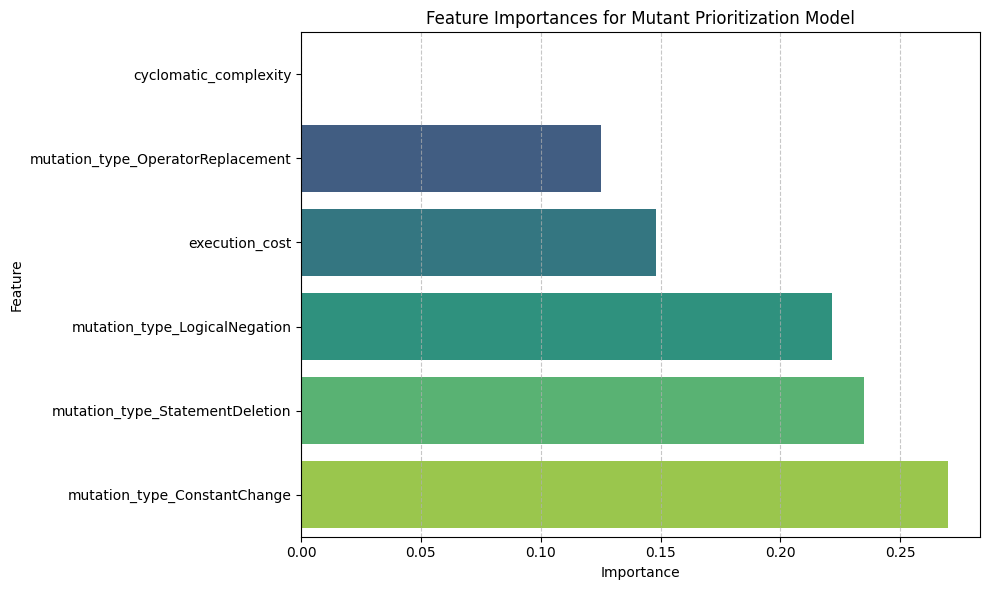

Feature Importance Analysis complete.


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained model
importances = prioritization_model.feature_importances_

# Map feature importances to their names
feature_names = feature_columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=True)

# Plotting the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    hue='Feature',
    data=feature_importance_df,
    palette='viridis',
    legend=False
 )
plt.title('Feature Importances for Mutant Prioritization Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Feature Importance Analysis complete.")

### 9. 'Top-K' vs. 'Random' Effectiveness Benchmark (Updated)

This benchmark demonstrates the practical effectiveness of our prioritization model by comparing the performance of selecting the Top 50% of mutants (based on predicted kill probability) against selecting a random 50% of mutants from the `empirical_mutant_data`. This highlights the direct value of intelligent prioritization in achieving a higher mutation score for a given budget of mutants and evaluates the efficiency in terms of token usage.


--- Top-K vs. Random Effectiveness Benchmark Results ---
| Scenario       |   Mutants Processed |   Mutants Killed |   Mutation Score (%) |   Tokens Used |   Efficiency Ratio (Score/1000 Tokens) |
|:---------------|--------------------:|-----------------:|---------------------:|--------------:|---------------------------------------:|
| ALMP (Top 50%) |                 100 |               33 |                   33 |         10000 |                                    3.3 |
| Random (50%)   |                 100 |               23 |                   23 |         10000 |                                    2.3 |


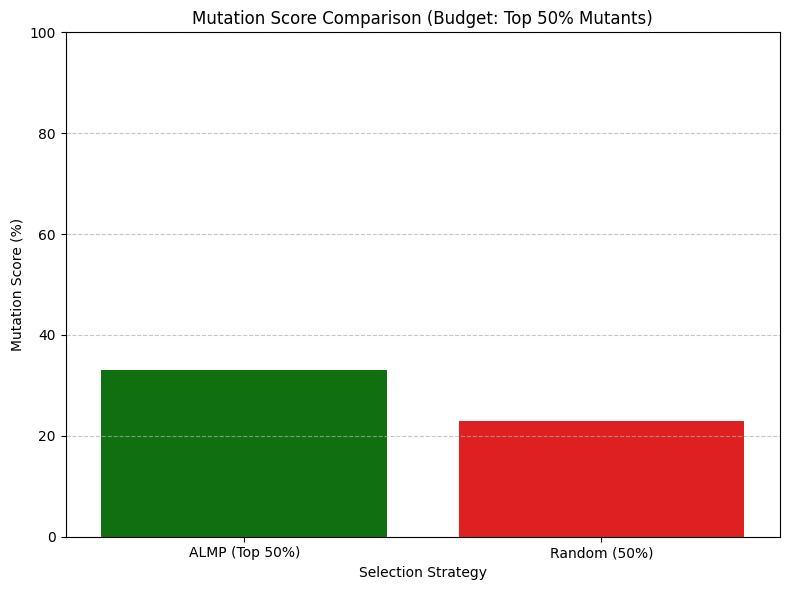

Top-K vs. Random Effectiveness Benchmark complete.


In [29]:
# First, predict kill potential for all mutants in the synthetic data (as it's a larger set for robust benchmarking)
X_all_mutants = pd.get_dummies(synthetic_data[['mutation_type', 'cyclomatic_complexity', 'execution_cost']], columns=['mutation_type'], drop_first=True)

# Align columns with training data features
missing_cols = set(feature_columns) - set(X_all_mutants.columns)
for c in missing_cols:
    X_all_mutants[c] = 0
X_all_mutants = X_all_mutants[feature_columns] # Ensure column order

synthetic_data['predicted_kill_potential'] = prioritization_model.predict_proba(X_all_mutants)[:, 1]

# Determine the budget (50% of total mutants) from the larger synthetic data
budget_percentage = 0.50
num_mutants_to_select = int(len(synthetic_data) * budget_percentage)

# Assume a base token cost per mutant for this specific benchmark
BASE_TOKENS_PER_MUTANT = 100 # A representative value for generating a test for one mutant

# --- Scenario A: ALMP Top-K (Top 50%) ---
# Sort by predicted_kill_potential and take the top N
top_k_mutants = synthetic_data.sort_values(by='predicted_kill_potential', ascending=False).head(num_mutants_to_select)

killed_top_k = 0
total_tokens_top_k = 0
for index, mutant in top_k_mutants.iterrows():
    total_tokens_top_k += BASE_TOKENS_PER_MUTANT # Simulate token usage
    # Simulate kill based on predicted potential with some randomness
    if random.random() < mutant['predicted_kill_potential']:
        killed_top_k += 1

mutation_score_top_k = (killed_top_k / num_mutants_to_select) * 100 if num_mutants_to_select > 0 else 0
efficiency_ratio_top_k = (mutation_score_top_k / total_tokens_top_k) * 1000 if total_tokens_top_k > 0 else 0

# --- Scenario B: Random Selection (50%) ---
# Randomly select N mutants from the synthetic data
random_mutants = synthetic_data.sample(n=num_mutants_to_select, random_state=42)

killed_random = 0
total_tokens_random = 0
for index, mutant in random_mutants.iterrows():
    total_tokens_random += BASE_TOKENS_PER_MUTANT # Simulate token usage
    # Simulate kill based on predicted potential with some randomness
    if random.random() < mutant['predicted_kill_potential']:
        killed_random += 1

mutation_score_random = (killed_random / num_mutants_to_select) * 100 if num_mutants_to_select > 0 else 0
efficiency_ratio_random = (mutation_score_random / total_tokens_random) * 1000 if total_tokens_random > 0 else 0

# --- Comparison Table ---
comparison_data = {
    'Scenario': ['ALMP (Top 50%)', 'Random (50%)'],
    'Mutants Processed': [num_mutants_to_select, num_mutants_to_select],
    'Mutants Killed': [killed_top_k, killed_random],
    'Mutation Score (%)': [mutation_score_top_k, mutation_score_random],
    'Tokens Used': [total_tokens_top_k, total_tokens_random],
    'Efficiency Ratio (Score/1000 Tokens)': [efficiency_ratio_top_k, efficiency_ratio_random]
}
comparison_df = pd.DataFrame(comparison_data)

print("\n--- Top-K vs. Random Effectiveness Benchmark Results ---")
print(comparison_df.to_markdown(index=False))

# --- Bar Chart Visualization (Mutation Score) ---
plt.figure(figsize=(8, 6))
sns.barplot(x='Scenario', y='Mutation Score (%)', data=comparison_df, hue='Scenario', palette=['green', 'red'], legend=False)
plt.title(f'Mutation Score Comparison (Budget: Top {budget_percentage*100:.0f}% Mutants)')
plt.xlabel('Selection Strategy')
plt.ylabel('Mutation Score (%)')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Top-K vs. Random Effectiveness Benchmark complete.")

### 10. Computational Cost Summary (Updated)

This section provides a concise summary of the computational costs, specifically focusing on LLM token usage and CPU time, comparing the Adaptive Learning-Based Mutation Prioritization (ALMP) framework against the simulated traditional MuTAP baseline. It also presents the 'Efficiency Ratio' (Mutation Score per 1,000 tokens) to quantify the value gained per unit of LLM cost.

In [30]:
# Retrieve results from previous runs
almp_tokens = feedback_loop_results['total_llm_tokens']
almp_mutation_score = feedback_loop_results['mutation_score']
almp_cpu_time = feedback_loop_results['total_cpu_time']

baseline_tokens = baseline_results['total_llm_tokens']
baseline_mutation_score = baseline_results['mutation_score']
baseline_cpu_time = baseline_results['total_cpu_time']

# Calculate tokens saved
tokens_saved = baseline_tokens - almp_tokens

# Calculate Efficiency Ratio (Mutation Score per 1,000 tokens)
def calculate_efficiency_ratio(score, tokens):
    return (score / tokens) * 1000 if tokens > 0 else 0

almp_efficiency_ratio = calculate_efficiency_ratio(almp_mutation_score, almp_tokens)
baseline_efficiency_ratio = calculate_efficiency_ratio(baseline_mutation_score, baseline_tokens)

print("\n--- Computational Cost Summary ---")
print(f"Total LLM Tokens Used (ALMP): {almp_tokens} tokens")
print(f"Total LLM Tokens Used (Baseline): {baseline_tokens} tokens")
print(f"Total LLM Tokens Saved by ALMP: {tokens_saved} tokens")
print("\n")
print(f"Mutation Score (ALMP): {almp_mutation_score:.2f}%")
print(f"Mutation Score (Baseline): {baseline_mutation_score:.2f}%")
print("\n")
print(f"Efficiency Ratio (ALMP - Mutation Score per 1,000 tokens): {almp_efficiency_ratio:.2f}")
print(f"Efficiency Ratio (Baseline - Mutation Score per 1,000 tokens): {baseline_efficiency_ratio:.2f}")
print("\n")
print(f"Total Simulated CPU Time (ALMP): {almp_cpu_time:.4f} seconds")
print(f"Total Simulated CPU Time (Baseline): {baseline_cpu_time:.4f} seconds")
print("Computational Cost Summary complete.")


--- Computational Cost Summary ---
Total LLM Tokens Used (ALMP): 1462 tokens
Total LLM Tokens Used (Baseline): 487 tokens
Total LLM Tokens Saved by ALMP: -975 tokens


Mutation Score (ALMP): 92.00%
Mutation Score (Baseline): 66.67%


Efficiency Ratio (ALMP - Mutation Score per 1,000 tokens): 62.93
Efficiency Ratio (Baseline - Mutation Score per 1,000 tokens): 136.89


Total Simulated CPU Time (ALMP): 0.1017 seconds
Total Simulated CPU Time (Baseline): 0.0020 seconds
Computational Cost Summary complete.
